# 1. Setup & Environment
- 공간 데이터 처리 및 통계 차트 렌더링 라이브러리 로드
- 한글 폰트(NanumGothic) 및 유니코드 마이너스 부호 환경 구성
- 판다스 실수 출력 포맷 및 컬럼 디스플레이 설정

In [1]:
# 1. 라이브러리 로드 및 환경 설정
from pathlib import Path
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# 폰트 및 유니코드 설정
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: "%.4f" % x)

# 2. Configuration & Cartographic Palette Definitions
- 서울시 집계구 폴리곤 및 모형별 점수 입출력 디렉터리(`output`, `output/maps`) 설정
- 25개 자치구 매핑 코드 및 학술 비교 차트 컬러 팔레트(2SFCA: Navy, Gravity: Red) 정의

In [2]:
# 2. 경로 및 분석 파라미터 정의
BASE_DIR = Path("/mnt/cowork/EV")
BOUNDARY_FP = BASE_DIR / "input/raw/집계구_2016/집계구.shp"

DIR_OUTPUT = BASE_DIR / "output"
DIR_MAPS = BASE_DIR / "output/maps"
DIR_OUTPUT.mkdir(parents=True, exist_ok=True)
DIR_MAPS.mkdir(parents=True, exist_ok=True)

OUT_CSV_MW = DIR_OUTPUT / "spike_2021_2022_by_dong_mw.csv"
OUT_PNG_MW = DIR_MAPS / "spike_2021_2022_by_dong_mw.png"

MODELS = ["2SFCA", "Gravity"]
TOP_N_GU = 5

# 서울시 25개 자치구 코드 매핑
GU_MAP = {
    "11010": "종로구", "11020": "중구", "11030": "용산구", "11040": "성동구", "11050": "광진구",
    "11060": "동대문구", "11070": "중랑구", "11080": "성북구", "11090": "강북구", "11100": "도봉구",
    "11110": "노원구", "11120": "은평구", "11130": "서대문구", "11140": "마포구", "11150": "양천구",
    "11160": "강서구", "11170": "구로구", "11180": "금천구", "11190": "영등포구", "11200": "동작구",
    "11210": "관악구", "11220": "서초구", "11230": "강남구", "11240": "송파구", "11250": "강동구",
}

# 학술 논문 및 포스터 표준 컬러 팔레트
PALETTE = {
    "2SFCA": "#2166ac",         # Academic Navy Blue
    "Gravity": "#d73027",       # Crimson Red
    "MUTED_BAR": "#c9c2ae",     # 비강조 구 막대 색상
    "TEXT": "#222222",          # 텍스트 색상
    "MUTED": "#666666",         # 부제 및 캡션
    "GRID": "#e0e0e0"           # 수평 보조선
}

print(f">> 분석 대상 모형: {MODELS} (2021년 vs 2022년 Δscore 분석)")
print(f">> 최종 산출물: {OUT_CSV_MW.name}, {OUT_PNG_MW.name}")

>> 분석 대상 모형: ['2SFCA', 'Gravity'] (2021년 vs 2022년 Δscore 분석)
>> 최종 산출물: spike_2021_2022_by_dong_mw.csv, spike_2021_2022_by_dong_mw.png


# 3. Boundary & Model Score Loaders
- 서울시 14,979개 집계구 폴리곤 및 행정동/구 메타데이터 로드
- 모형별 2021년 및 2022년 점수 파일 탐색 함수 구현 (`_mw.csv` 우선 참조)

In [3]:
# 3. 경계 및 점수 데이터 로더
def load_seoul_boundary(boundary_path: Path) -> gpd.GeoDataFrame:
    """서울시 집계구(코드 11 시작) 경계 로드 및 행정동/구 속성 정의"""
    gdf = gpd.read_file(boundary_path)
    gdf = gdf.set_crs(epsg=5179, allow_override=True)
    gdf["TOT_REG_CD"] = gdf["TOT_REG_CD"].astype(str)
    
    gdf_seoul = gdf[gdf["TOT_REG_CD"].str.startswith("11")][["TOT_REG_CD", "ADM_NM", "geometry"]].copy()
    gdf_seoul["gu"] = gdf_seoul["TOT_REG_CD"].str[:5].map(GU_MAP)
    return gdf_seoul.reset_index(drop=True)

gdf_seoul = load_seoul_boundary(BOUNDARY_FP)
print(f">> 서울시 집계구 속성 로드 완료: 총 {len(gdf_seoul):,}개 집계구")

def resolve_score_file(model: str, year: int) -> Path:
    """모형별 접근성 점수 CSV 경로 탐색 (_mw 우선)"""
    if model == "2SFCA":
        fp_mw = BASE_DIR / f"output/g2sfca_sfast_final_gaussian/g2sfca_score_{year}_week_낮_normal_mw.csv"
        if fp_mw.exists():
            return fp_mw
        return BASE_DIR / f"output/g2sfca_sfast_final_gaussian/g2sfca_score_{year}_week_낮_normal.csv"
    elif model == "Gravity":
        fp_mw = BASE_DIR / f"output/gravity_model_gaussian/gravity_score_{year}_week_낮_normal_mw.csv"
        if fp_mw.exists():
            return fp_mw
        return BASE_DIR / f"output/gravity_model_gaussian/gravity_score_{year}_week_낮_normal.csv"
    return None

>> 서울시 집계구 속성 로드 완료: 총 19,153개 집계구


# 4. Spatiotemporal Spike Decomposition Engine (Gu & Dong Level)
- 집계구별 $\Delta \text{score} = \text{score}_{2022} - \text{score}_{2021}$ 산출
- 1차: 25개 자치구별 증가분 점유율 및 상위 5개 구 집중도 계산
- 2차: 상위 5개 자치구 내부 행정동 단위 증가분 순위 및 집중도 분해
- 모형별 결과 병합 후 최종 CSV(`spike_2021_2022_by_dong_mw.csv`) 저장

In [4]:
# 4. 구 및 동 단위 접근성 급증 분해 연산
print("=" * 80)
print("RUNNING: 2021->2022 ACCESSIBILITY SPIKE DECOMPOSITION (GU & DONG)")
print("=" * 80)

model_results = {}
all_exported_rows = []

for model in MODELS:
    fp_21 = resolve_score_file(model, 2021)
    fp_22 = resolve_score_file(model, 2022)
    
    s21 = pd.read_csv(fp_21, dtype={"oa_code": str}).set_index("oa_code")["accessibility_score"]
    s22 = pd.read_csv(fp_22, dtype={"oa_code": str}).set_index("oa_code")["accessibility_score"]
    
    df_m = gdf_seoul[["TOT_REG_CD", "ADM_NM", "gu"]].copy()
    delta_series = (s22 - s21).fillna(0.0)
    df_m["delta"] = df_m["TOT_REG_CD"].map(delta_series).fillna(0.0)
    df_m["model"] = model
    all_exported_rows.append(df_m)
    
    # 1. 자치구 단위 증가분 집계
    gu_sum = df_m.groupby("gu")["delta"].sum().sort_values(ascending=False)
    total_delta = gu_sum.sum()
    gu_share = (gu_sum / total_delta) * 100.0
    top5_share = gu_share.head(TOP_N_GU).sum()
    top_gu_list = gu_share.head(TOP_N_GU).index.tolist()
    
    # 2. 상위 5개 자치구 내부 행정동 단위 집계
    within_top_gu = df_m[df_m["gu"].isin(top_gu_list)]
    within_total_delta = within_top_gu["delta"].sum()
    dong_sum = within_top_gu.groupby(["gu", "ADM_NM"])["delta"].sum().sort_values(ascending=False)
    top5_dong_share = (dong_sum.head(5).sum() / within_total_delta) * 100.0
    
    model_results[model] = {
        "gu_share": gu_share,
        "top5_share": top5_share,
        "top_gu_list": top_gu_list,
        "dong_sum": dong_sum,
        "within_total_delta": within_total_delta,
        "top5_dong_share": top5_dong_share
    }
    
    print(f"\n[{model}] 자치구 증가분 상위 5개 구: {', '.join(top_gu_list)}")
    print(f"  - 상위 {TOP_N_GU}개 구 집중도 : {top5_share:.2f}% (전체 서울시 증가분 대비)")
    print(f"  - 상위구 내 상위 5개 동 집중도: {top5_dong_share:.2f}% (상위 5개 구 증가분 대비)")

# 집계구 레벨 전체 결과 CSV 내보내기 (_mw)
df_final_export = pd.concat(all_exported_rows, ignore_index=True)
df_final_export.to_csv(OUT_CSV_MW, index=False, encoding="utf-8-sig")
print(f"\n>> 집계구별 전이 데이터 저장 완료: {OUT_CSV_MW.name} (총 {len(df_final_export):,}행)")

RUNNING: 2021->2022 ACCESSIBILITY SPIKE DECOMPOSITION (GU & DONG)

[2SFCA] 자치구 증가분 상위 5개 구: 송파구, 강남구, 서초구, 강서구, 관악구
  - 상위 5개 구 집중도 : 32.50% (전체 서울시 증가분 대비)
  - 상위구 내 상위 5개 동 집중도: 12.49% (상위 5개 구 증가분 대비)

[Gravity] 자치구 증가분 상위 5개 구: 송파구, 강남구, 양천구, 서초구, 노원구
  - 상위 5개 구 집중도 : 32.46% (전체 서울시 증가분 대비)
  - 상위구 내 상위 5개 동 집중도: 9.58% (상위 5개 구 증가분 대비)

>> 집계구별 전이 데이터 저장 완료: spike_2021_2022_by_dong_mw.csv (총 38,306행)


# 5. Summary Pivot & Cross-Model Concentration Comparison
- 2SFCA vs Gravity 모형 간 자치구별 증가분 점유율 상위 10개 구 및 행정동 Top 10 상세 비교표 출력
- 특정 모형 의존적 왜곡인지 실제 공급 인프라 집중 현상인지 교차 검증

In [5]:
# 5. 모형별 집중도 비교 요약표
print("=" * 80)
print("             2021->2022 자치구별 증가분 점유율 상위 10개 구 비교")
print("=" * 80)

df_gu_comp = pd.DataFrame({
    "2SFCA 점유율(%)": model_results["2SFCA"]["gu_share"].head(10),
    "Gravity 점유율(%)": model_results["Gravity"]["gu_share"].head(10)
})
display(df_gu_comp)

print("\n" + "=" * 80)
print("             상위 5개 자치구 내부 행정동 Top 10 증가 점유율 비교")
print("=" * 80)

top_dong_2s = model_results["2SFCA"]["dong_sum"].head(10)
top_dong_gr = model_results["Gravity"]["dong_sum"].head(10)

df_dong_2s = pd.DataFrame({
    "2SFCA 행정동": [f"{g} {d}" for g, d in top_dong_2s.index],
    "2SFCA 증가량": top_dong_2s.values,
    "상위구내 점유율(%)": (top_dong_2s.values / model_results["2SFCA"]["within_total_delta"]) * 100.0
})

df_dong_gr = pd.DataFrame({
    "Gravity 행정동": [f"{g} {d}" for g, d in top_dong_gr.index],
    "Gravity 증가량": top_dong_gr.values,
    "상위구내 점유율(%)": (top_dong_gr.values / model_results["Gravity"]["within_total_delta"]) * 100.0
})

display(pd.concat([df_dong_2s, df_dong_gr], axis=1))

             2021->2022 자치구별 증가분 점유율 상위 10개 구 비교


,2SFCA 점유율(%),Gravity 점유율(%)
gu,,
강남구,6.6783,6.5615
강서구,6.1865,5.4931
관악구,5.7646,4.0895
구로구,4.7320,4.9782
노원구,5.7036,5.8442
도봉구,4.8444,NaN
서초구,6.4086,6.1478
송파구,7.4654,7.7403
양천구,5.5995,6.1663



             상위 5개 자치구 내부 행정동 Top 10 증가 점유율 비교


,2SFCA 행정동,2SFCA 증가량,상위구내 점유율(%),Gravity 행정동,Gravity 증가량,상위구내 점유율(%)
0,강남구 세곡동,0.0144,3.4778,노원구 월계3동,2572.3108,2.0421
1,서초구 양재2동,0.0105,2.5360,양천구 목5동,2432.5547,1.9311
2,서초구 양재1동,0.0104,2.5212,서초구 양재1동,2410.3510,1.9135
3,강서구 발산1동,0.0082,1.9840,노원구 공릉1동,2397.7714,1.9035
4,서초구 내곡동,0.0082,1.9721,양천구 신정3동,2260.5498,1.7946
5,강서구 화곡1동,0.0080,1.9307,강남구 세곡동,2243.9720,1.7814
6,송파구 장지동,0.0078,1.8939,서초구 서초3동,2149.3182,1.7063
7,강남구 개포4동,0.0067,1.6257,노원구 중계2·3동,2069.6408,1.6430
8,서초구 서초3동,0.0067,1.6234,송파구 삼전동,2050.0376,1.6275
9,강서구 우장산동,0.0061,1.4712,송파구 석촌동,2006.8501,1.5932


# 6. Multi-Panel Comparative Visualization (2 Rows x 2 Columns)
- 2행 2열 서브플롯 구성
  * 좌측 열: 25개 자치구별 $\Delta \text{score}$ 점유율 막대 차트 (상위 5개 구 하이라이트)
  * 우측 열: 상위 5개 구 내부 행정동 단위 Top 15 수평 막대 차트
- 포스터 및 논문 발표 규격(300 DPI) 고해상도 이미지(`spike_2021_2022_by_dong_mw.png`) 저장

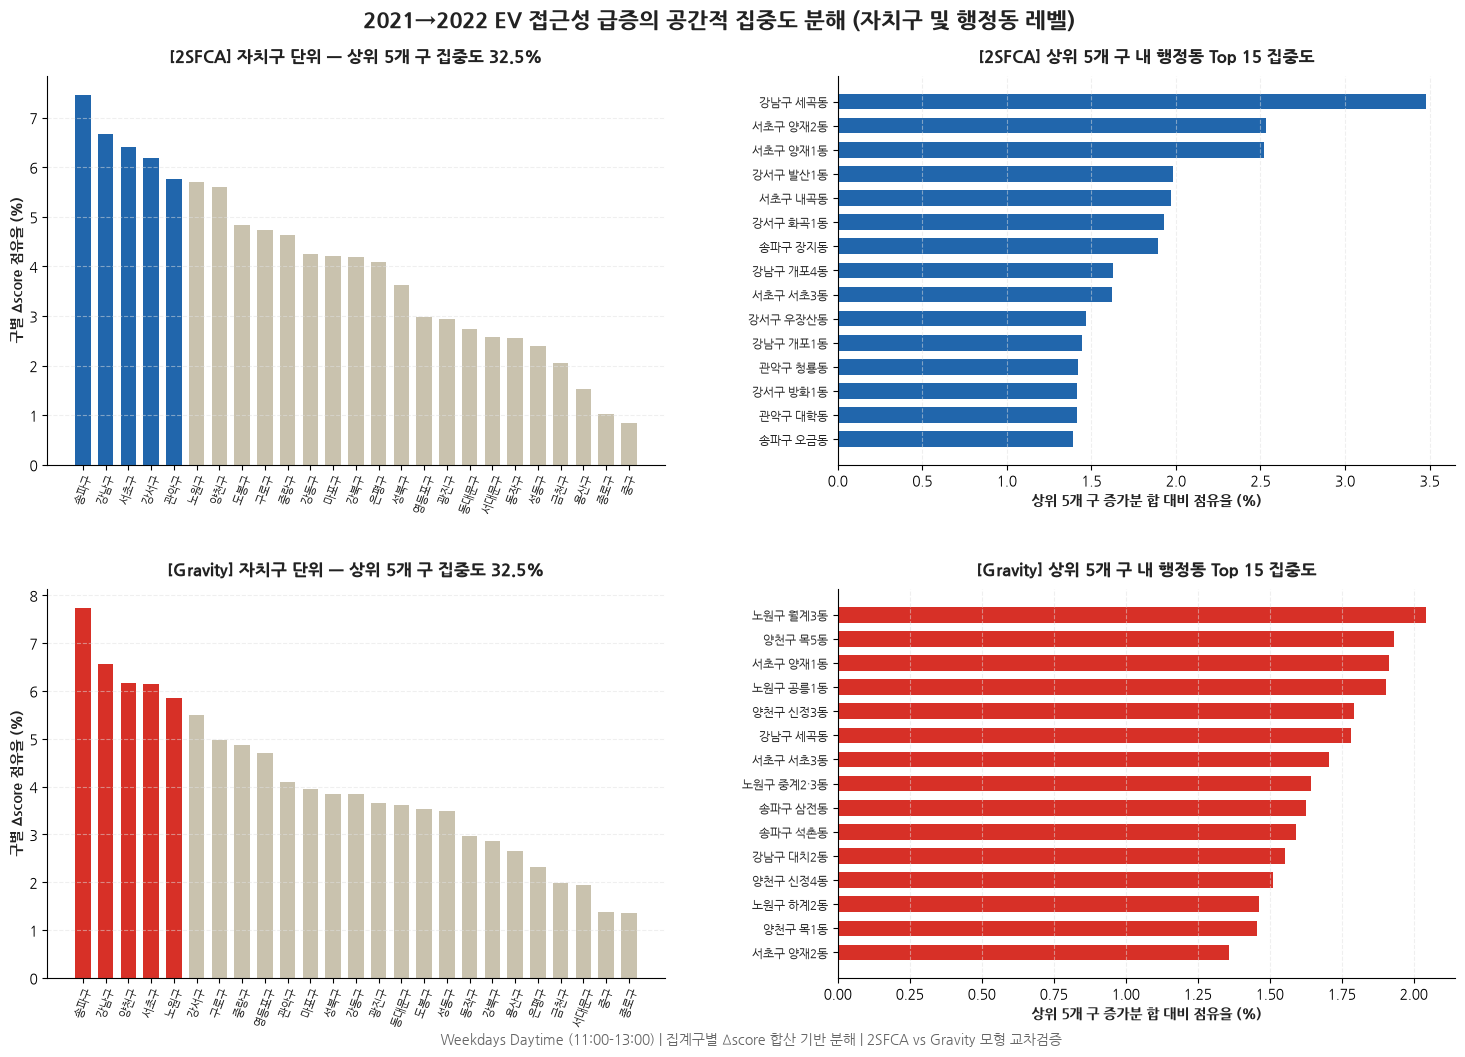


>> 2x2 분해 비교 차트 고해상도 저장 완료: spike_2021_2022_by_dong_mw.png


In [6]:
# 6. 2x2 비교 차트 시각화 및 고해상도 내보내기
fig, axes = plt.subplots(2, 2, figsize=(16, 11), facecolor="white")
plt.subplots_adjust(top=0.90, bottom=0.08, left=0.08, right=0.96, hspace=0.32, wspace=0.28)

for mi, model in enumerate(MODELS):
    res = model_results[model]
    gu_share = res["gu_share"]
    top_gu_list = res["top_gu_list"]
    dong_sum = res["dong_sum"]
    within_total = res["within_total_delta"]
    top5_share = res["top5_share"]
    
    # --- [좌측: 구 단위 점유율 막대 차트] ---
    ax_gu = axes[mi, 0]
    bar_colors = [PALETTE[model] if g in top_gu_list else PALETTE["MUTED_BAR"] for g in gu_share.index]
    
    ax_gu.bar(range(len(gu_share)), gu_share.values, color=bar_colors, width=0.68)
    ax_gu.set_xticks(range(len(gu_share)))
    ax_gu.set_xticklabels(gu_share.index, rotation=70, fontsize=8, color=PALETTE["TEXT"])
    ax_gu.set_ylabel("구별 Δscore 점유율 (%)", fontsize=10, fontweight="bold", color=PALETTE["TEXT"])
    ax_gu.set_title(
        f"[{model}] 자치구 단위 — 상위 {TOP_N_GU}개 구 집중도 {top5_share:.1f}%",
        fontsize=12, fontweight="bold", color=PALETTE["TEXT"], pad=10
    )
    ax_gu.spines[["top", "right"]].set_visible(False)
    ax_gu.grid(axis="y", linestyle="--", alpha=0.5, color=PALETTE["GRID"])

    # --- [우측: 상위구 내부 행정동 Top 15 수평 막대] ---
    ax_dong = axes[mi, 1]
    top_dong = dong_sum.head(15)
    labels = [f"{g} {d}" for g, d in top_dong.index]
    shares = (top_dong.values / within_total) * 100.0
    
    ax_dong.barh(range(len(top_dong)), shares[::-1], color=PALETTE[model], height=0.65)
    ax_dong.set_yticks(range(len(top_dong)))
    ax_dong.set_yticklabels(labels[::-1], fontsize=8.5, color=PALETTE["TEXT"])
    ax_dong.set_xlabel("상위 5개 구 증가분 합 대비 점유율 (%)", fontsize=10, fontweight="bold", color=PALETTE["TEXT"])
    ax_dong.set_title(
        f"[{model}] 상위 {TOP_N_GU}개 구 내 행정동 Top 15 집중도",
        fontsize=12, fontweight="bold", color=PALETTE["TEXT"], pad=10
    )
    ax_dong.spines[["top", "right"]].set_visible(False)
    ax_dong.grid(axis="x", linestyle="--", alpha=0.5, color=PALETTE["GRID"])

# 메인 타이틀 및 분석 메타데이터 캡션
fig.suptitle(
    "2021→2022 EV 접근성 급증의 공간적 집중도 분해 (자치구 및 행정동 레벨)",
    fontsize=15.5, fontweight="bold", color=PALETTE["TEXT"], y=0.96
)
fig.text(
    0.52, 0.02,
    "Weekdays Daytime (11:00-13:00) | 집계구별 Δscore 합산 기반 분해 | 2SFCA vs Gravity 모형 교차검증",
    ha="center", fontsize=10, color=PALETTE["MUTED"]
)

# 파일 내보내기 (300 DPI)
fig.savefig(OUT_PNG_MW, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f"\n>> 2x2 분해 비교 차트 고해상도 저장 완료: {OUT_PNG_MW.name}")

# 7. Output & Data Integrity Verification
- 신규 생성된 CSV 및 300 DPI 이미지 파일의 존재 여부 및 용량(MB) 점검
- 기존 원본 CSV(`spike_2021_2022_by_dong.csv`)와의 수치 일치성 전수 검증

In [7]:
# 7. 산출물 파일 상태 및 수치 정밀 검증
fp_orig_csv = DIR_OUTPUT / "spike_2021_2022_by_dong.csv"

print("=" * 80)
print("             산출물 생성 확인 및 무결성 검증 요약")
print("=" * 80)

# 이미지 및 CSV 파일 확인
for fp in [OUT_CSV_MW, OUT_PNG_MW]:
    if fp.exists():
        size_mb = fp.stat().st_size / (1024 * 1024)
        print(f"  [V] {fp.name:<32} : 정상 생성 완료 ({size_mb:.2f} MB)")
    else:
        print(f"  [X] {fp.name:<32} : 파일 누락 확인 필요")

# 원본 CSV와의 수치 오차 검증
if fp_orig_csv.exists() and OUT_CSV_MW.exists():
    df_orig = pd.read_csv(fp_orig_csv, dtype={"TOT_REG_CD": str})
    df_new = pd.read_csv(OUT_CSV_MW, dtype={"TOT_REG_CD": str})
    
    comp = df_orig.merge(df_new, on=["model", "TOT_REG_CD"], suffixes=("_orig", "_new"))
    max_diff = (comp["delta_orig"] - comp["delta_new"]).abs().max()
    
    print("-" * 80)
    print(f"- 원본 vs 리팩토링 Δscore 최대 절대 오차: {max_diff:.8f}")
    if max_diff < 1e-5:
        print(">> [판정] 2SFCA 및 Gravity 모형의 모든 구·동 분해 수치가 원본과 완벽히 일치합니다.")
    else:
        print(">> [판정] 수치 오차가 발견되었습니다. 세부 레코드를 점검해주세요.")

             산출물 생성 확인 및 무결성 검증 요약
  [V] spike_2021_2022_by_dong_mw.csv   : 정상 생성 완료 (2.28 MB)
  [V] spike_2021_2022_by_dong_mw.png   : 정상 생성 완료 (0.55 MB)
--------------------------------------------------------------------------------
- 원본 vs 리팩토링 Δscore 최대 절대 오차: 0.00000000
>> [판정] 2SFCA 및 Gravity 모형의 모든 구·동 분해 수치가 원본과 완벽히 일치합니다.
